# Adversarial Attacks using API

Example notebook showcasing implemented adversarial attacks for object detection for the PascalVOC dataset.

## DPATCH Attack

In [1]:
import torch
from advsecurenet.models.model_factory import ModelFactory
from advsecurenet.datasets.dataset_factory import DatasetFactory
from advsecurenet.dataloader.data_loader_factory import DataLoaderFactory
from advsecurenet.shared.types.configs.preprocess_config import (
    PreprocessConfig,
    PreprocessStep,
)
from advsecurenet.shared.types.configs.device_config import DeviceConfig
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
from advsecurenet.shared.types import DatasetType
from advsecurenet.models.CustomODModels.CustomYolov5Model import CustomYolov5Model
from advsecurenet.models.od_wrapper import  ODWrapper
from advsecurenet.models.CustomODModels.CustomFasterRCNNModel import CustomFasterRCNNModel
from advsecurenet.computer_vision.object_detection.attacks.adversarial_patch_based.dpatch import DPatchAttackConfig, DPatch

/Users/fabienmorgan/Desktop/Ausbildung/Master/Masters_Project/Code/venv_master_project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/fabienmorgan/Desktop/Ausbildung/Master/Masters_Project/Code/advsecurenet_mp/advsecurenet/datasets/base_dataset.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### Model initialization

FasterRCNNModel initialization.

In [2]:
architecture = {
    "num_classes": 91,
}
model = ModelFactory.create_model(
    model_name="CustomFasterRCNNModel", 
    pretrained=False, 
    is_external=True,
    model_weights_path=None,
    model_arch_path="../../../advsecurenet/models/CustomODModels/CustomFasterRCNNModel.py",
    architecture=architecture,
)

Getting object detector model names...


### Dataset initialization

Define the PreprocessConfig.

In [3]:
clip_max = 255.0
preprocess_config = PreprocessConfig(steps=[
    PreprocessStep(name="Resize", params={"size": (640, 640)}),
    # Turn a H×W×C numpy array (0–255) into a FloatTensor C×H×W in [0,1]
    PreprocessStep(name="ToTensor"),
    # Cast dtype to float32
    PreprocessStep(name="ToDtype", params={"dtype": "torch.float32"}),
])

PascalVOC dataset initialization.

<span style="color:red"><strong>WARNING:</strong></span>  
The Pascal VOC dataset may fail to download due to firewall restrictions. When this occurs, a small HTML file—approximately **5 KB** in size—may appear in the `advsecurenet/data` directory with the name `VOCtrainval_11-May-2012.tar`.  

In a successful download, a file with the same name will be present, but its size should be approximately **2 GB**.

If the dataset was not downloaded correctly, please manually download the dataset files by opening the URLs listed below in your web browser. After downloading, place the files in the `advsecurenet/data` directory and replace the incorrect HTML file.

**Dataset URLs:**
- https://data.brainchip.com/dataset-mirror/voc/VOCtrainval_06-Nov-2007.tar
- https://data.brainchip.com/dataset-mirror/voc/VOCtest_06-Nov-2007.tar
- https://data.brainchip.com/dataset-mirror/voc/VOCtrainval_11-May-2012.tar


In [4]:
# Alternatively - use PascalVOC
# (this dataset takes some time (up to 10 minutes) to load)

test_data = DatasetFactory.load_dataset(
    dataset_name="PASCAL_VOC",
    preprocessing=preprocess_config,
)

Reduce the dataset to a few samples (to save computational time).

In [5]:
# reducing test_data to n samples for testing purposes
from torch.utils.data import Subset
test_data = test_data["test"]
if 'test_data' in locals() and hasattr(test_data, '__len__') and hasattr(test_data, '__getitem__'):
    original_len = len(test_data)
    num_samples_to_keep = 10
    if original_len == 0:
        print("test_data is empty. Cannot create a subset.")
    elif original_len < num_samples_to_keep:
        print(f"test_data has only {original_len} sample(s), which is less than the desired {num_samples_to_keep}. Using all available {original_len} sample(s).")
    else:
        subset_indices = list(range(num_samples_to_keep))
        test_data = Subset(test_data, subset_indices)
        print(f"Reduced test_data from {original_len} to {len(test_data)} samples.")
else:
    print("Warning: 'test_data' for PascalVOC dataset not found or is not a valid dataset. Please ensure it's loaded correctly in a previous cell.")


Reduced test_data from 5823 to 10 samples.


Create a DataLoader.

In [6]:
dataloader = DataLoaderFactory.create_od_dataloader(dataset=test_data, batch_size=5, num_workers=0)

### Plotting function

In [7]:
%matplotlib inline
import requests
from torchvision import transforms
import cv2
from advsecurenet.computer_vision.object_detection.utils import extract_predictions
from advsecurenet.datasets.label_utils import resolve_label_names
# assume input_batch_np is N×H×W×C, dtype uint8 or float in [0,255]
import numpy as np
from PIL import Image

# assume each img_t is either [C,H,W] or [1,C,H,W], *normalized* with mean/std
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])


def plot_image_with_boxes(img, boxes, pred_cls, title):
    text_size = 1
    text_th = 3
    rect_th = 2
    for i in range(len(boxes)):
        cv2.rectangle(img, (int(boxes[i][0][0]), int(boxes[i][0][1])), (int(boxes[i][1][0]), int(boxes[i][1][1])),
                      color=(0, 255, 0), thickness=rect_th)
        # Write the prediction class
        cv2.putText(img, pred_cls[i], (int(boxes[i][0][0]), int(boxes[i][0][1])), cv2.FONT_HERSHEY_SIMPLEX, text_size,
                    (0, 255, 0), thickness=text_th)
    plt.figure()
    plt.axis("off")
    plt.title(title)
    plt.imshow(img.astype(np.uint8), interpolation="nearest")
    plt.show()


def plot_images(adv_imgs, detector, title, conf_th=0.7):
    pil_imgs = []
    if adv_imgs and len(adv_imgs[0]) > 0: # Check if adv_imgs[0] is not empty
        for img_t in adv_imgs[0]:
            if img_t.dim() == 4:
                img_t = img_t[0]
            arr = img_t.permute(1,2,0).cpu().numpy()
            arr = np.clip(arr*255, 0, 255).astype(np.uint8)
            pil_imgs.append(Image.fromarray(arr))
    else:
        print("adv_imgs[0] is empty or adv_imgs is not populated correctly.")
    imgs_np_hwc = [np.array(p) for p in pil_imgs]       # each shape (H,W,3)
    if imgs_np_hwc: # Check if there are images to process
        imgs_np_nchw = np.stack([arr.transpose(2,0,1)     # (H,W,3) → (3,H,W)
                                for arr in imgs_np_hwc],
                                axis=0)
        dets = detector.predict(imgs_np_nchw)
        model_obj = getattr(detector, "model", detector)
        label_names = resolve_label_names(model=model_obj, dataset_name="PASCAL_VOC")
        for img_nchw, det in zip(imgs_np_nchw, dets):
            cls, boxes, scores = extract_predictions(det, conf_th, label_names=label_names)
            img_hwc_display = img_nchw.transpose(1,2,0).copy()
            plot_image_with_boxes(img_hwc_display, boxes, cls, title)
    else:
        print("No images processed to display.")

In [12]:
from advsecurenet.models.detector_factory import get_object_detector
device_name = "mps"
device = DeviceConfig(processor=device_name)
object_detector_config = {
    "input_shape": (3, 640, 640),
    "device_type": device_name,
    "clip_values": (0.0, clip_max),
    "conf_thresh": 0.25,
}
detector = get_object_detector(config=object_detector_config, existing_model=model.model)

# define the device config
device = DeviceConfig(processor=device_name)
config = DPatchAttackConfig(
    object_detector=detector,
    patch_shape=(3, 200, 200),
    learning_rate=1.99,
    max_iter=800,
    target_label=None,  # None for untargeted attack
    device=device,
)
attack = DPatch(config)


### Baseline - detections on clean images

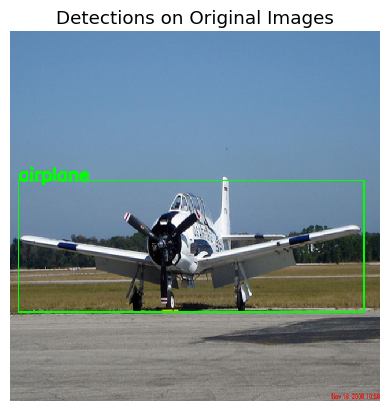

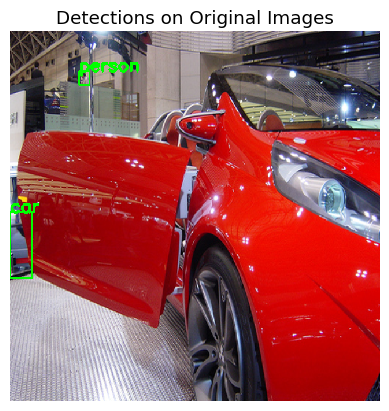

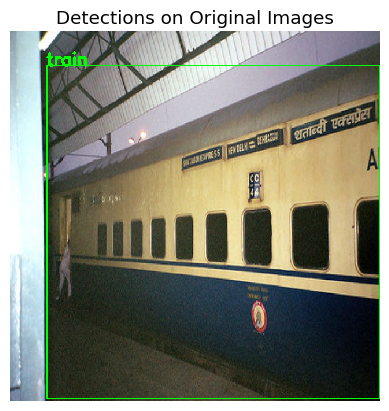

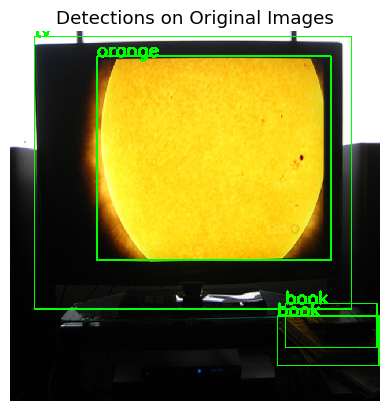

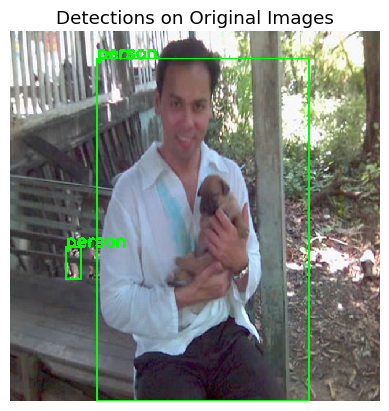

In [13]:
import os
from PIL import Image

original_images, targets = next(iter(dataloader))

# 2) make a save‐folder (if it doesn’t already exist)
save_dir = "saved_images"
os.makedirs(save_dir, exist_ok=True)

# 3) loop & write each image
#    assuming `images` is a tensor of shape (B, C, H, W) in [0..1]
for i, img in enumerate(original_images):
    # bring to CPU, convert to H×W×C uint8
    np_img = (img
              .detach()
              .cpu()
              .permute(1, 2, 0)
              .numpy()
              * 255
             ).astype("uint8")
    Image.fromarray(np_img).save(os.path.join(save_dir, f"img_{i:03d}.png"))

plot_images([original_images], detector, title="Detections on Original Images")


### Option 1. Using the Attacker


In [ ]:
from advsecurenet.computer_vision.object_detection.attacks.attacker import AdversarialPatchODAttacker
from advsecurenet.shared.types.configs.attack_configs.od_attacker_config import (
    ODAttackerConfig,
)

attacker_config = ODAttackerConfig(
    model=model,
    attack=attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
)
attacker = AdversarialPatchODAttacker(config=attacker_config)
adv_imgs = attacker.execute()

original_images = adv_imgs[0]  # Get the first batch of adversarial images

DPatch iteration:   0%|          | 1/800 [15:35<207:42:35, 935.86s/it]

In [ ]:
plot_images([adv_imgs[0]], detector, title="Detections on Adversarial Images - Attacker")

### Option 2. Manual Iteration

If you prefer to manually run the attack, you can loop through the dataloader to generate the adversarial samples. 

In [ ]:
learned_patch = attack.attack(
    dataloader=dataloader,
    device=device.processor,
    mask=None
)

In [ ]:
images_for_plotting_tensor, _ = next(iter(dataloader))
images_for_attack = (images_for_plotting_tensor.to(device.processor) * 255.0).detach()

# Apply the learned universal patch to the batch of images
patched_np = attack.apply_patch(
        x              = images_for_attack,
        patch_external = learned_patch.detach().cpu().numpy(),
        random_location=False
)

# Plot the results
patched_tensor = (patched_np / 255.0).to(detector.device)
plot_images([patched_tensor], detector, title="Detections on Patched Images - Manual Iteration")

### DPatch - With Target Label


In [ ]:
from advsecurenet.models.detector_factory import get_object_detector
target_label = 40  # Example target label, change as needed
# define the device config
device = DeviceConfig(processor=device_name)
config_targeted = DPatchAttackConfig(
    object_detector=detector,
    patch_shape=(3, 200, 200),
    learning_rate=1.99,
    max_iter=800,
    target_label=target_label,  # for targeted attack
    device=device,
)
attack_targeted = DPatch(config_targeted)

### Option 1. Using the Attacker

In [ ]:
from advsecurenet.computer_vision.object_detection.attacks.attacker import AdversarialPatchODAttacker
from advsecurenet.shared.types.configs.attack_configs.od_attacker_config import (
    ODAttackerConfig,
)

attacker_config = ODAttackerConfig(
    model=model,
    attack=attack_targeted,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
)
attacker = AdversarialPatchODAttacker(config=attacker_config)
adv_imgs = attacker.execute()
original_images = adv_imgs[0]  # Get the first batch of adversarial images

In [ ]:
plot_images([original_images], detector, title="Detections on Adversarial Images - Attacker")

### Option 2. Manual Iteration

In [ ]:
learned_patch = attack_targeted.attack(
    dataloader=dataloader,
    mask=None,
    device=device.processor
)

images_for_plotting_tensor, _ = next(iter(dataloader))
images_for_attack = (images_for_plotting_tensor.to(device.processor) * 255.0).detach()

# Apply the learned universal patch to the batch of images
patched_np = attack.apply_patch(
        x              = images_for_attack,
        patch_external = learned_patch.detach().cpu().numpy(),
        random_location=False
)

# Plot the results
patched_tensor = (patched_np / 255.0).to(detector.device)

In [ ]:
plot_images([patched_tensor], detector, title="Detections on Patched Images - Manual Iteration")

## TOG Attack

If you ran DPatch attacks in this notebook, prior to running the TOG Attacks, for their best performance, restart the Kernel and rerun top cells from this notebook, up until (including) cell labelled as *Baseline - detections on clean images*.

### TOG FABRICATION

### Option 1 - Using the Attacker

In [ ]:
from advsecurenet.computer_vision.object_detection.attacks.pixel_perturbation_based.tog.tog import TOGAttackConfig, TOG
from advsecurenet.computer_vision.object_detection.attacks.pixel_perturbation_based.tog.tog_attack_type import TOGAttackType
tog_config = TOGAttackConfig(
    object_detector=detector,
    max_iter=130,
    eps = 24 / 255.,
    eps_iter = 2.0 / 255.0,#0.0001,
)
tog_attack = TOG(tog_config)

In [ ]:
from advsecurenet.shared.types.configs.attack_configs.od_attacker_config import (
    ODAttackerConfig,
)
from advsecurenet.computer_vision.object_detection.attacks.attacker import PixelPerturbationODAttacker
tog_attacker_config = ODAttackerConfig(
    model=model,
    attack=tog_attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
)
tog_attacker = PixelPerturbationODAttacker(config=tog_attacker_config, attack_type=TOGAttackType.FABRICATION)
tog_adv_imgs = tog_attacker.execute()

original_images = tog_adv_imgs[0]  # Get the first batch of adversarial images
plot_images([original_images], detector, title="[TOG FABRICATION] Detections on Adversarial Images")

### Option 2 - Manual Iteration

In [ ]:
all_adv_imgs = []
for batch_images_tensor, batch_targets_dict in tqdm(dataloader, desc="Attacking"):
    batch_images = batch_images_tensor.to(device.processor)            # (B,3,H,W) in [0,1]
    images_for_attack = (batch_images).detach().cpu().numpy()              # now [0,255]
    adv_imgs = tog_attack.attack(
        x            = images_for_attack,
        tog_variant  = TOGAttackType.FABRICATION,
    )
    all_adv_imgs.extend(adv_imgs)

original_images = torch.from_numpy(np.array(all_adv_imgs))  # Get the first batch of adversarial images
plot_images([original_images[:5]], detector, title="[TOG FABRICATION] Detections on Adversarial Images")

### TOG VANISHING

### Option 1. Using the Attacker

In [ ]:
from advsecurenet.computer_vision.object_detection.attacks.pixel_perturbation_based.tog.tog import TOGAttackConfig, TOG
from advsecurenet.computer_vision.object_detection.attacks.pixel_perturbation_based.tog.tog_attack_type import TOGAttackType
tog_config = TOGAttackConfig(
    object_detector=detector,
    max_iter=400,
    eps = 32 / 255.,
    eps_iter = 2.0 / 255.0,
)
tog_attack = TOG(tog_config)

In [ ]:
from advsecurenet.computer_vision.object_detection.attacks.attacker import PixelPerturbationODAttacker
from advsecurenet.shared.types.configs.attack_configs.od_attacker_config import (
    ODAttackerConfig,
)

tog_attacker_config = ODAttackerConfig(
    model=model,
    attack=tog_attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
)
tog_attacker = PixelPerturbationODAttacker(config=tog_attacker_config, attack_type=TOGAttackType.VANISHING)
tog_adv_imgs = tog_attacker.execute()
original_images = tog_adv_imgs[0]  # Get the first batch of adversarial images
plot_images([original_images], detector, title="[TOG VANISHING] Detections on Adversarial Images")

### Option 2. Manual Iteration

In [ ]:
all_adv_imgs = []
for batch_images_tensor, batch_targets_dict in tqdm(dataloader, desc="Attacking"):
    batch_images = batch_images_tensor.to(device.processor)            # (B,3,H,W) in [0,1]
    images_for_attack = (batch_images).detach().cpu().numpy()              # now [0,255]
    adv_imgs = tog_attack.attack(
        x            = images_for_attack,
        tog_variant  = TOGAttackType.VANISHING,
    )
    all_adv_imgs.extend(adv_imgs)
original_images = torch.from_numpy(np.array(all_adv_imgs))  # Get the first batch of adversarial images
plot_images([original_images[:5]], detector, title="[TOG VANISHING] Detections on Adversarial Images")

### TOG UNTARGETED

### Option 1 - Using the Attacker

In [ ]:
from advsecurenet.computer_vision.object_detection.attacks.pixel_perturbation_based.tog.tog import TOGAttackConfig, TOG
from advsecurenet.computer_vision.object_detection.attacks.pixel_perturbation_based.tog.tog_attack_type import TOGAttackType
tog_config = TOGAttackConfig(
    object_detector=detector,
    max_iter=100,
    eps = 12 / 255.,
    eps_iter = 1.5 / 255.0,#0.0001,
)
tog_attack = TOG(tog_config)

In [ ]:
from advsecurenet.computer_vision.object_detection.attacks.attacker import PixelPerturbationODAttacker
from advsecurenet.shared.types.configs.attack_configs.od_attacker_config import (
    ODAttackerConfig,
)

tog_attacker_config = ODAttackerConfig(
    model=model,
    attack=tog_attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
)

tog_attacker = PixelPerturbationODAttacker(config=tog_attacker_config, attack_type=TOGAttackType.UNTARGETED)
tog_adv_imgs = tog_attacker.execute()

original_images = tog_adv_imgs[0]  # Get the first batch of adversarial images
plot_images([original_images], detector, title="[TOG UNTARGETED] Detections on Adversarial Images")

### Option 2 - Manual Iteration

In [ ]:
all_adv_imgs = []
for batch_images_tensor, batch_targets_dict in tqdm(dataloader, desc="Attacking"):
    batch_images = batch_images_tensor.to(device.processor)            # (B,3,H,W) in [0,1]
    images_for_attack = (batch_images).detach().cpu().numpy()              # now [0,255]
    adv_imgs = tog_attack.attack(
        x            = images_for_attack,
        tog_variant  = TOGAttackType.UNTARGETED,
    )
    all_adv_imgs.extend(adv_imgs)

original_images = torch.from_numpy(np.array(all_adv_imgs))  # Get the first batch of adversarial images
plot_images([original_images[:5]], detector, title="[TOG UNTARGETED] Detections on Adversarial Images")

### TOG MISLABELING

### Option 1 - Using the Attacker

In [ ]:
from advsecurenet.computer_vision.object_detection.attacks.pixel_perturbation_based.tog.tog import TOGAttackConfig, TOG
from advsecurenet.computer_vision.object_detection.attacks.pixel_perturbation_based.tog.tog_attack_type import TOGAttackType
tog_config = TOGAttackConfig(
    object_detector=detector,
    max_iter=100,
    eps = 24 / 255.,
    eps_iter = 1.5 / 255.0,#0.0001,
)
tog_attack = TOG(tog_config)

In [ ]:
# Most Likely (ML) mode
from advsecurenet.shared.types.configs.attack_configs.od_attacker_config import (
    ODAttackerConfig,
)
from advsecurenet.computer_vision.object_detection.attacks.attacker import PixelPerturbationODAttacker
tog_attacker_config = ODAttackerConfig(
    model=model,
    attack=tog_attack,
    dataloader=dataloader,
    device=device,
    return_adversarial_images=True,
)
# For Most Likely (ML) mode - targets most probable alternative class
tog_attacker_ml = PixelPerturbationODAttacker(config=tog_attacker_config, 
                                         attack_type=TOGAttackType.MISLABELING, 
                                         tog_mislabeling_mode="ML")
tog_adv_imgs = tog_attacker_ml.execute()
original_images = tog_adv_imgs[0]  # Get the batch of adversarial images
plot_images([original_images], detector, title="[TOG MISLABELING ML] Detections on Adversarial Images")

In [ ]:
# Least Likely (LL) mode - targets least probable class
tog_attacker_ll = PixelPerturbationODAttacker(config=tog_attacker_config, 
                                         attack_type=TOGAttackType.MISLABELING, 
                                         tog_mislabeling_mode="LL")
tog_adv_imgs = tog_attacker_ll.execute()
original_images = tog_adv_imgs[0]  # Get the batch of adversarial images
plot_images([original_images], detector, title="[TOG MISLABELING LL] Detections on Adversarial Images")

### Option 2 - Manual Iteration

In [ ]:
# ML Mode
all_adv_imgs = []
for batch_images_tensor, batch_targets_dict in tqdm(dataloader, desc="Attacking"):
    batch_images = batch_images_tensor.to(device.processor)            # (B,3,H,W) in [0,1]
    images_for_attack = (batch_images).detach().cpu().numpy()              # now [0,255]
    adv_imgs = tog_attack.attack(
        x            = images_for_attack,
        tog_variant  = TOGAttackType.MISLABELING,
        tog_mislabeling_mode="ML",
    )
    all_adv_imgs.extend(adv_imgs)

original_images = torch.from_numpy(np.array(all_adv_imgs))  # Get the first batch of adversarial images
plot_images([original_images[:5]], detector, title="[TOG MISLABELING ML] Detections on Adversarial Images")

In [ ]:
# LL Mode
all_adv_imgs = []
for batch_images_tensor, batch_targets_dict in tqdm(dataloader, desc="Attacking"):
    batch_images = batch_images_tensor.to(device.processor)            # (B,3,H,W) in [0,1]
    images_for_attack = (batch_images).detach().cpu().numpy()              # now [0,255]
    adv_imgs = tog_attack.attack(
        x            = images_for_attack,
        tog_variant  = TOGAttackType.MISLABELING,
        tog_mislabeling_mode="LL",
    )
    all_adv_imgs.extend(adv_imgs)

original_images = torch.from_numpy(np.array(all_adv_imgs))  # Get the batch of adversarial images
plot_images([original_images[:5]], detector, title="[TOG MISLABELING LL] Detections on Adversarial Images")